In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
train = pd.read_csv('data/train.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
test = pd.read_csv('data/test.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
events = pd.read_csv('data/events.csv.gz', parse_dates=['event_ts'])

In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 11091 entries, 0 to 11090
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   cookie_id          11091 non-null  str           
 1   cookie_created_at  11091 non-null  datetime64[us]
 2   window_start_ts    11091 non-null  datetime64[us]
 3   window_end_ts      11091 non-null  datetime64[us]
 4   target             11091 non-null  int64         
dtypes: datetime64[us](3), int64(1), str(1)
memory usage: 639.2 KB


In [5]:
len(train)

11091

In [6]:
train['cookie_id'].nunique()

11091

In [7]:
len(test)

4909

In [8]:
test['cookie_id'].nunique()

4909

In [9]:
test[test['cookie_id'].isin(train['cookie_id'].unique())]

,cookie_id,cookie_created_at,window_start_ts,window_end_ts


In [10]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 4909 entries, 0 to 4908
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   cookie_id          4909 non-null   str           
 1   cookie_created_at  4909 non-null   datetime64[us]
 2   window_start_ts    4909 non-null   datetime64[us]
 3   window_end_ts      4909 non-null   datetime64[us]
dtypes: datetime64[us](3), str(1)
memory usage: 244.6 KB


In [11]:
print("TEST ")
print(f"MIN: {test['window_start_ts'].min()}")
print(f"MAX start: {test['window_start_ts'].max()}")

print(f"mAx end: {test['window_end_ts'].max()}")

print("\nTRAIN ")
print(f"MIN: {train['window_start_ts'].min()}")
print(f"MAX start: {train['window_start_ts'].max()}")

print(f"mAx end : {train['window_end_ts'].max()}")

TEST 
MIN: 2026-04-20 00:00:00
MAX start: 2026-04-26 00:00:00
mAx end: 2026-04-27 00:00:00

TRAIN 
MIN: 2026-04-06 00:00:00
MAX start: 2026-04-19 00:00:00
mAx end : 2026-04-20 00:00:00


In [12]:
(train['window_end_ts'] - train['window_start_ts']).value_counts()

1 days    11091
Name: count, dtype: int64

In [13]:
#inner - so it becomes train
events = events.merge(train, on='cookie_id' )
events = events[(events.event_ts >= events.window_start_ts) & (events.event_ts < events.window_end_ts)]

In [14]:
test[test['cookie_id'].isin(events['cookie_id'].unique())]

,cookie_id,cookie_created_at,window_start_ts,window_end_ts


In [15]:
events.info()

<class 'pandas.DataFrame'>
Index: 198436 entries, 0 to 239214
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   cookie_id          198436 non-null  str           
 1   event_ts           198436 non-null  datetime64[us]
 2   eid                198436 non-null  int64         
 3   event_name         198436 non-null  str           
 4   platform           198436 non-null  str           
 5   user_agent         198436 non-null  str           
 6   item_id            132819 non-null  float64       
 7   item_category      182802 non-null  str           
 8   item_location      188610 non-null  str           
 9   seller_type        120778 non-null  str           
 10  search_query       61717 non-null   str           
 11  search_page        61717 non-null   float64       
 12  pointer_x          66243 non-null   float64       
 13  pointer_y          66243 non-null   float64       
 14  cook

In [16]:
len(events)

198436

In [17]:
print("УНИКальные элементы")
for col in events.columns:
    print(f"{col} :  {events[col].nunique()}")

УНИКальные элементы
cookie_id :  11091
event_ts :  178059
eid :  9
event_name :  9
platform :  11
user_agent :  148
item_id :  46953
item_category :  15
item_location :  40
seller_type :  2
search_query :  120
search_page :  43
pointer_x :  1921
pointer_y :  1081
cookie_created_at :  11085
window_start_ts :  14
window_end_ts :  14
target :  2


In [18]:
events["search_page"].value_counts()

search_page
1.0     24048
2.0     13676
3.0      8288
4.0      5230
5.0      3281
6.0      2155
7.0      1401
8.0       949
9.0       716
10.0      459
11.0      338
12.0      256
13.0      198
14.0      153
15.0      132
16.0       92
18.0       60
17.0       56
20.0       42
19.0       38
21.0       26
23.0       19
22.0       17
25.0       14
24.0        9
26.0        8
28.0        7
29.0        6
33.0        6
31.0        5
32.0        5
27.0        5
35.0        5
30.0        4
36.0        3
34.0        2
45.0        2
48.0        1
39.0        1
40.0        1
41.0        1
63.0        1
42.0        1
Name: count, dtype: int64

In [19]:
events["search_query"].value_counts()

search_query
шкаф купе                 599
джинсы levis              589
toyota camry              580
renault logan             576
вторичка 2к               575
                         ... 
подработка                462
вакансия оператор         460
macbook air m1            455
апартаменты аренда        453
снять квартиру у метро    434
Name: count, Length: 120, dtype: int64

In [20]:
events["search_query"].str.lower().str.strip().value_counts()

search_query
шкаф купе                 599
джинсы levis              589
toyota camry              580
renault logan             576
вторичка 2к               575
                         ... 
подработка                462
вакансия оператор         460
macbook air m1            455
апартаменты аренда        453
снять квартиру у метро    434
Name: count, Length: 120, dtype: int64

In [21]:
events["eid"].value_counts()

eid
200    74338
100    61717
210    22951
400    12037
220    10688
300     7046
500     3900
301     3780
303     1979
Name: count, dtype: int64

In [22]:
events["event_name"].value_counts()

event_name
item_view               74338
search_results_view     61717
photo_swipe             22951
favorite_add            12037
seller_page_view        10688
contact_phone_show       7046
login                    3900
contact_chat_open        3780
contact_message_sent     1979
Name: count, dtype: int64

In [23]:
events['platform'].value_counts()

platform
desktop    27855
Web        27470
WEB        27431
web        27251
ANDROID    26209
Android    25893
android    25889
IOS         2634
iOS         2626
iphone      2602
ios         2576
Name: count, dtype: int64

In [24]:
events['item_location'].value_counts()

item_location
sankt-peterburg     24676
novosibirsk         23533
moskva              23169
ekaterinburg        23098
ryazan               2933
omsk                 2803
barnaul              2787
astrahan             2774
kazan                2763
rostov-na-donu       2758
krasnodar            2740
izhevsk              2732
kirov                2723
saratov              2718
tyumen               2710
vladivostok          2669
volgograd            2658
tomsk                2652
ufa                  2640
kemerovo             2610
yaroslavl            2602
nizhniy_novgorod     2591
ulyanovsk            2580
lipetsk              2572
cheboksary           2569
penza                2557
ivanovo              2553
krasnoyarsk          2543
voronezh             2543
tolyatti             2520
kaliningrad          2511
perm                 2507
chelyabinsk          2503
tula                 2502
bryansk              2491
orenburg             2490
irkutsk              2488
habarovsk            247

In [25]:
events["item_location"].str.lower().str.strip().value_counts()

item_location
sankt-peterburg     24676
novosibirsk         23533
moskva              23169
ekaterinburg        23098
ryazan               2933
omsk                 2803
barnaul              2787
astrahan             2774
kazan                2763
rostov-na-donu       2758
krasnodar            2740
izhevsk              2732
kirov                2723
saratov              2718
tyumen               2710
vladivostok          2669
volgograd            2658
tomsk                2652
ufa                  2640
kemerovo             2610
yaroslavl            2602
nizhniy_novgorod     2591
ulyanovsk            2580
lipetsk              2572
cheboksary           2569
penza                2557
ivanovo              2553
krasnoyarsk          2543
voronezh             2543
tolyatti             2520
kaliningrad          2511
perm                 2507
chelyabinsk          2503
tula                 2502
bryansk              2491
orenburg             2490
irkutsk              2488
habarovsk            247

In [26]:
events['item_category'].value_counts()

item_category
avtomobili           13158
mebel                12688
kvartiry_prodazha    12531
hobbi                12514
odezhda              12453
uslugi               12213
noutbuki             12178
elektronika          12162
telefony             12137
bytovaya_tehnika     12108
detskie_tovary       12063
rabota               11849
kvartiry_arenda      11848
zapchasti            11515
zhivotnye            11385
Name: count, dtype: int64

In [27]:

events['seller_type'].value_counts()

seller_type
private    69729
pro        51049
Name: count, dtype: int64

In [28]:
print(events['event_ts'].max())
print(events['event_ts'].min())

2026-04-19 23:59:50
2026-04-06 00:02:57


In [29]:
events.head(10)['event_ts']

0    2026-04-13 12:02:56
1    2026-04-08 06:12:14
2    2026-04-12 17:16:05
4    2026-04-11 16:08:12
5    2026-04-10 16:50:05
7    2026-04-13 15:29:38
8    2026-04-15 20:38:42
9    2026-04-10 01:45:25
10   2026-04-11 18:31:31
11   2026-04-19 14:23:02
Name: event_ts, dtype: datetime64[us]

In [30]:
events['user_agent'].value_counts()

user_agent
Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 YaBrowser/23.0.0.0 Safari/537.36     2330
Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 YaBrowser/23.11.0.0 Safari/537.36    2254
Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36                  2252
Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/117.0.0.0 YaBrowser/23.9.0.0 Safari/537.36     2182
Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 YaBrowser/23.3.0.0 Safari/537.36     2181
                                                                                                                                       ... 
python-urllib3/2.0.7                                                                                                                    667
Mozilla/5

In [31]:
print(events.isna().mean().round(3))

cookie_id            0.000
event_ts             0.000
eid                  0.000
event_name           0.000
platform             0.000
user_agent           0.000
item_id              0.331
item_category        0.079
item_location        0.050
seller_type          0.391
search_query         0.689
search_page          0.689
pointer_x            0.666
pointer_y            0.666
cookie_created_at    0.000
window_start_ts      0.000
window_end_ts        0.000
target               0.000
dtype: float64


In [32]:
points_null = events[events[['pointer_x', 'pointer_y']].isna().any(axis=1)]

In [33]:
len(points_null) # 328905 - all, 220365 - хотя бы один отсутствует

132193

In [34]:
len(events[events[['pointer_x', 'pointer_y']].isna().all(axis=1)]) #одинаково, если отсутствуют , то оба

132193

In [35]:
len(events[events[['search_query', 'search_page']].isna().any(axis=1)])

136719

In [36]:
len(events[events[['search_query', 'search_page']].isna().all(axis=1)]) #если отсутствуют, то вместе search_page and query

136719

In [37]:
len(events[events[['search_query', 'search_page','pointer_x', 'pointer_y']].isna().all(axis=1)]) #есть пересечения

90948

In [38]:
for col in points_null.columns:
    print(f"{col} : {points_null[col].nunique()}")

cookie_id : 8984
event_ts : 122080
eid : 9
event_name : 9
platform : 11
user_agent : 148
item_id : 38760
item_category : 15
item_location : 40
seller_type : 2
search_query : 120
search_page : 42
pointer_x : 0
pointer_y : 0
cookie_created_at : 8981
window_start_ts : 14
window_end_ts : 14
target : 2


### EVENTS находки
- len(events) == 328_905
- скорее категориальные признаки: eid, item_category, seller_type, event_name, platform, item_location
- platform - по сути привести только к desktop, web, android, ios
- eid, event_name связаны: зачем хранить оба?
- item_ (loca, cat) - без происшетсвий
- СОДЕРЖИТ И ТЕСТОВУЮ И ТРЕНИРОВОЧНУЮ ВЫБОРКУ!!!!
- не отсортированно по датам
- user_agent есть как устройства, так и запросы с кода
- search_page всего 46, а есть и 63
- poiter_x и pointer_y если отстсутствуют, то вместе
- если отсутствуют, то вместе search_page and query
- есть пересечения когда нет search_... and pointer_...

#### Небольшие вопросы
- связаны ли как-то eid (200 и 210 ) или можно спокойно делать категорией
- превращать ил search_page into category

### TRAIN and TEst
- наблюдение идет 1 день
- по времени пересечений нет у train, test
- пересений по cookie_id тоже нет

In [39]:
events = events.sort_values(['cookie_id', 'event_ts'])

In [40]:
mapping_platform = {
    'web':'web',
    'android':'android',
    'ios':'ios',
    'iphone':'ios',
    'desktop':'desktop'
}

events['platform'] = (events['platform'].str.lower().str.strip().map(mapping_platform))

In [41]:
print(events['platform'].value_counts())
print("\n", events['platform'].isna().mean())

platform
web        82152
android    77991
desktop    27855
ios        10438
Name: count, dtype: int64

 0.0


In [42]:
categorical_cols = ['platform', 'item_category', 'seller_type', 'event_name']

### Checlk
- пропадают pointer_x, pointer_y у кого (eid, cookie id)
- event_name и eid точно одно и тоже
- тайм гэп между действия одной куки 

### Подозрение
- кто заходит на авито с помощью бибилотек?



In [43]:
events['pointers_null'] = events[['pointer_x', 'pointer_y']].isna().all(axis=1)

In [44]:
no_pointers_check_cookie = events.groupby(['cookie_id']).agg(
    n = ('event_ts', 'size'),
    null = ('pointers_null', 'sum'),
    mean = ('pointers_null', 'mean'),
    
    
)

In [45]:
diff_cookie = (no_pointers_check_cookie['n'] - no_pointers_check_cookie['null']).sort_values(ascending=False)

diff_cookie[diff_cookie==0].count()

np.int64(7045)

In [46]:
len(diff_cookie)

11091

In [47]:
diff_cookie

cookie_id
ck_69e4a26a1d5a7604    135
ck_c0145a60548546fb    128
ck_25907a736fb5e5d0    123
ck_d274382b19488771    119
ck_edd37d8c0e06c7d6    119
                      ... 
ck_005802d8a4215738      0
ck_004ea2031eb47626      0
ck_0049e76146165462      0
ck_00436d6b09c98735      0
ck_00433ddd95d069b1      0
Length: 11091, dtype: int64

In [48]:
null_pointers_target_cookie = diff_cookie[diff_cookie==0].reset_index().merge(train[['target', 'cookie_id']], on='cookie_id')

In [49]:
null_pointers_target_cookie['target'].value_counts()

target
0    6397
1     648
Name: count, dtype: int64

In [50]:
diff_mask_cookie = diff_cookie == 0
diff_mask_cookie

cookie_id
ck_69e4a26a1d5a7604    False
ck_c0145a60548546fb    False
ck_25907a736fb5e5d0    False
ck_d274382b19488771    False
ck_edd37d8c0e06c7d6    False
                       ...  
ck_005802d8a4215738     True
ck_004ea2031eb47626     True
ck_0049e76146165462     True
ck_00436d6b09c98735     True
ck_00433ddd95d069b1     True
Length: 11091, dtype: bool

In [51]:
events = events.merge(diff_mask_cookie.rename('no_pointers_cookie'), on='cookie_id')

In [52]:
events['no_pointers_cookie'].isna().sum()

np.int64(0)

In [53]:
no_pointers_check_cookie['mean'].describe()

count    11091.000000
mean         0.653592
std          0.459622
min          0.000000
25%          0.062500
50%          1.000000
75%          1.000000
max          1.000000
Name: mean, dtype: float64

In [54]:
no_pointers_check_eid = events.groupby(['eid']).agg(
    n = ('event_ts', 'size'),
    null = ('pointers_null', 'sum'),
    cookies = ('cookie_id', 'nunique'),
    mean = ('pointers_null', 'mean')
    
)

In [55]:
diff_eid = (no_pointers_check_eid['n'] - no_pointers_check_eid['null']).sort_values(ascending=False)

diff_eid[diff_eid==0].count()

np.int64(0)

<Axes: xlabel='eid'>

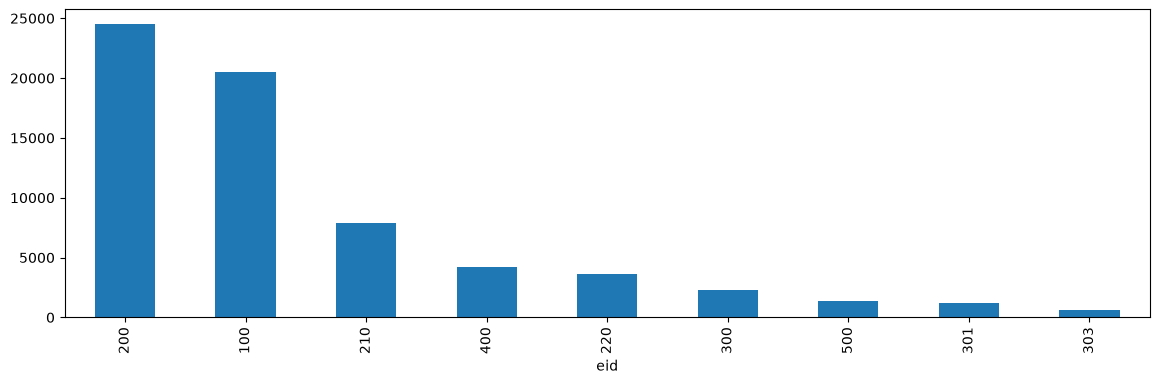

In [56]:
diff_eid.plot(kind='bar', figsize=(14, 4))

In [57]:
diff_eid

eid
200    24517
100    20472
210     7863
400     4227
220     3636
300     2302
500     1396
301     1187
303      643
dtype: int64

In [58]:
no_pointers_check_eid

,n,null,cookies,mean
eid,,,,
100,61717,41245,10170,0.668292
200,74338,49821,10362,0.670196
210,22951,15088,8101,0.657401
220,10688,7052,5651,0.659805
300,7046,4744,3894,0.673290
301,3780,2593,2559,0.685979
303,1979,1336,1549,0.675088
400,12037,7810,5985,0.648833
500,3900,2504,2913,0.642051


In [59]:
no_pointers_check_platform = events.groupby(['platform']).agg(
    n = ('event_ts', 'size'),
    null = ('pointers_null', 'sum'),
    cookies = ('cookie_id', 'nunique'),
    mean = ('pointers_null', 'mean'),
    # здесь считать target_0 не надо, потому что sum даст сумму по кукам, в которых одна может повторяться!
    
)
diff_plat= (no_pointers_check_platform['n'] - no_pointers_check_platform['null']).sort_values(ascending=False)

diff_plat[diff_plat==0].count()

np.int64(2)

<Axes: xlabel='platform'>

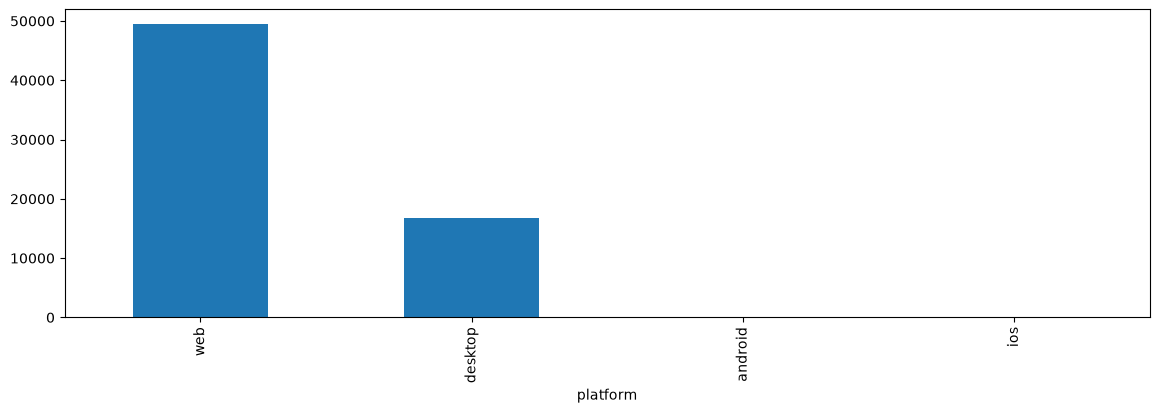

In [60]:
diff_plat.plot(kind='bar', figsize=(14, 4))

<Axes: xlabel='platform'>

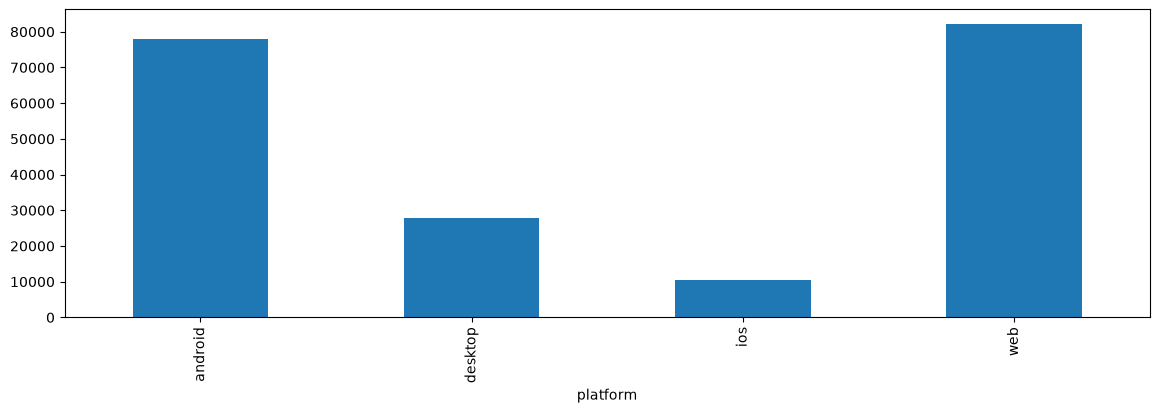

In [61]:
no_pointers_check_platform['n'].plot(kind='bar', figsize=(14, 4))

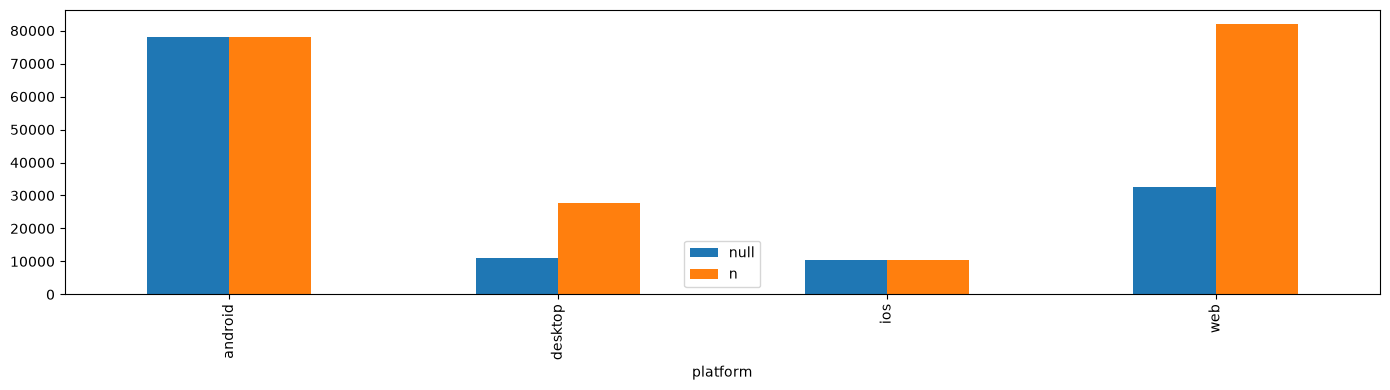

In [62]:
df_platform_nulls_pointers = pd.DataFrame({
    'null': no_pointers_check_platform['null'],
    'n': no_pointers_check_platform['n'],
})

fig, ax = plt.subplots(figsize=(14, 4))
df_platform_nulls_pointers.plot(kind='bar',  ax=ax)
plt.tight_layout()
plt.show()

In [63]:
NON_PHONES = ['desktop', 'web']


In [64]:
# у нетелефонов какие таргетвы
for col in NON_PHONES:
    min_dataset = events[events['platform']==col]
    cookie_targets = min_dataset.groupby('cookie_id')['target'].first()

    print(f" {col}  ", cookie_targets.value_counts())

 desktop   target
0    4703
1     567
Name: count, dtype: int64
 web   target
0    5278
1     588
Name: count, dtype: int64


In [65]:
platforms_per_cookie = events.groupby('cookie_id').agg(
    n_platforms = ('platform','nunique'),
    target = ('target', 'first')
)
platforms_per_cookie.sort_values(by='n_platforms',ascending=False)

,n_platforms,target
cookie_id,,
ck_ff61d8701342c78d,2,0
ck_ff5ff4693d8786c9,2,0
ck_ff40ab072bb56a88,2,0
ck_ff2fa3bea92b310e,2,0
ck_ff2ee76fb5d3b661,2,0
...,...,...
ck_00389b209b37394b,1,1
ck_0037dcb6ec6b40c4,1,0
ck_0032c08d8987d0ad,1,0


In [66]:
platforms_per_cookie.reset_index().groupby(['n_platforms']).agg(
    bots = ('target', 'sum'),
    people = ('target', lambda s: (s==0).sum())
)

,bots,people
n_platforms,,
1,332,5540
2,567,4652


In [67]:
cookie_platforms = events.groupby('cookie_id').agg(
    platforms = ('platform', lambda s: '+'.join(sorted(s.unique()))),
    n_platforms = ('platform', 'nunique'),
    target = ('target', 'first'),
)

cookie_platforms['platforms'].value_counts()



platforms
desktop+web    5219
android        4595
web             647
ios             579
desktop          51
Name: count, dtype: int64

In [68]:
cookie_platforms = cookie_platforms.merge(diff_mask_cookie.rename('no_pointers_cookie'), on='cookie_id', how='left')
cookie_platforms.head(0)

,platforms,n_platforms,target,no_pointers_cookie
cookie_id,,,,


In [69]:
combo_stats = cookie_platforms.groupby('platforms').agg(
    n_cookies = ('target', 'size'),
    bots = ('target', 'sum'),
    people = ('target', lambda s: (s==0).sum()),
    no_pointers_cookie = ('no_pointers_cookie', 'mean'),
    mean_bots = ('target', 'mean')
).sort_values('bots', ascending=False)

combo_stats

,n_cookies,bots,people,no_pointers_cookie,mean_bots
platforms,,,,,
desktop+web,5219,567,4652,0.321518,0.108642
android,4595,285,4310,1.000000,0.062024
ios,579,26,553,1.000000,0.044905
web,647,21,626,0.284389,0.032457
desktop,51,0,51,0.176471,0.000000


In [70]:
cookie_platforms[cookie_platforms.platforms=='desktop+web'].groupby('no_pointers_cookie')['target'].mean()

no_pointers_cookie
False    0.068907
True     0.192491
Name: target, dtype: float64

In [71]:
cookie_platforms[cookie_platforms.platforms=='web'].groupby('no_pointers_cookie')['target'].mean()

no_pointers_cookie
False    0.015119
True     0.076087
Name: target, dtype: float64

In [72]:
cookie_null_share = events.groupby('cookie_id')['pointers_null'].mean().rename('pointer_null_share')

cookie_platforms = cookie_platforms.merge(cookie_null_share, on='cookie_id', how='left')
cookie_platforms[['pointer_null_share', 'no_pointers_cookie']].describe()


,pointer_null_share
count,11091.000000
mean,0.653592
std,0.459622
min,0.000000
25%,0.062500
50%,1.000000
75%,1.000000
max,1.000000


In [73]:
mask_dw = cookie_platforms['platforms'] == 'desktop+web'
share = cookie_platforms.loc[mask_dw, 'pointer_null_share']

bins = pd.qcut(share, q=5, duplicates='drop')
cookie_platforms.loc[mask_dw].groupby(bins)['target'].agg(['mean', 'size'])
# так как до этого наверху показано, что у нас с половины уже 1, то схлопнулись некоторые бины
#собственно, где-то у нас схлопнулась 50%-100%, а можеет и ниже 50

,mean,size
pointer_null_share,,
"(-0.001, 0.0455]",0.064347,2098
"(0.0455, 0.125]",0.085768,1061
"(0.125, 1.0]",0.165534,2060


In [74]:



pointer_group = pd.cut(
    share,
    bins=[-0.001, 0.125, 0.999, 1.0],
    labels=['почти всегда есть курсор', 'частично без курсора', 'курсора нет вообще'],
)

cookie_platforms.loc[mask_dw].groupby(pointer_group)['target'].agg(['mean', 'size'])
#нет монотонности при qcut
#скорее лучше оставить бианрный признак

,mean,size
pointer_null_share,,
почти всегда есть курсор,0.071542,3159
частично без курсора,0.047120,382
курсора нет вообще,0.192491,1678


### FOUND
- полностью нет курсора у 7045 из 11091 cookie
- из этиъ безкурсовшиков 6397 - ЛЮДИ
- полностью безкурсовщиков для какой-то eid нет
- скорее все это связано с тем, что на телефонах нет курсора, но надо проверить, что реально используется вообще больше телеофны


-  у какой-то платформмы также нет выраженного ботства
- cookies максимум используют 2 платформы, и таких больше >=50 and <=75
- из кобминаций у нас есть только desk+web, бот не сидит ЧИСТО на ноутбуке
- desk+web

diff_mask_cookie + null_pointers_target_cookie - получаем таблицу
- ВИД               Люди       Боты         ВСЕГО
- Нет курсора       6397       648          7045
- ЕСТЬ              3795       251          4046
- ИТОГО             10192      899          11091

- people_true = 6397/10192 = 0.6276
- bots_true = 648/899 = 0.7208
- TRUE = ln(0.62../0.72..) = -0.139
- ln(people_false/bot_false) = 0.288
- IV = (0.6276-0.7208)на(-0.139) + (0.3724-0.2792) на 0.288 = 0.0129 + 0.0268 = 0.040
- НА ВСЮ ВЫБОРКУ НЕ ПОДХОДИТ

для desktop+web

Бин   Люди  Боты  Всего 

True   1355  323   1678  

False 3297  244   3541  

Итого  4652  567   5219

-  ln(people_true/bots_true) = -0.671
-  ln(p_false/b_false) = 0.499

IV = 0.499
- НАВЕРНОЕ МОЖНО 

In [75]:
# для простоты
def calc_iv(df, feature, target, bins=None, eps=1e-6):
    

    x = df[feature]
    if bins is not None:
        x = pd.cut(x, bins=bins, duplicates='drop', include_lowest=True)

    g = df.groupby(x)[target].agg(n='count', n_bot='sum')
    g['n_human'] = g['n'] - g['n_bot']

    total_bot = g['n_bot'].sum()
    total_human = g['n_human'].sum()

    g['pct_bot'] = g['n_bot'] / total_bot
    g['pct_human'] = g['n_human'] / total_human

    # eps защищает от log(0), если в каком-то бине все — одного класса
    g['woe'] = np.log((g['pct_human'] + eps) / (g['pct_bot'] + eps))
    g['iv_bin'] = (g['pct_human'] - g['pct_bot']) * g['woe']

    return g, g['iv_bin'].sum()

In [76]:
table_all, iv_all = calc_iv(cookie_platforms, 'no_pointers_cookie', 'target')
print(iv_all)


table_dw, iv_dw = calc_iv(cookie_platforms[mask_dw], 'no_pointers_cookie', 'target')
print(iv_dw)

0.03970984122507208
0.3256335668287965


In [77]:

mask_web = cookie_platforms['platforms'] == 'web'
table_w, iv_w = calc_iv(cookie_platforms[mask_web], 'no_pointers_cookie', 'target')
print(iv_w)
# только вот  web	647	21 из таблицы наверху, так что шум 

0.6637058603128969


In [78]:
#валидация в quickstart была прям рядом, с 17  - проверить надо б отже
def check_near(dataset, filter = None):
    #надо посичтать влияние комбинаций платформ и ноль указателя на ботство
    #но они должны быть чистые, поэтому группируем по cookies_id для начала
    dataset = dataset[dataset.window_start_ts.ge('2026-04-17')]

    cookies_plat = dataset.groupby('cookie_id').agg(
        platforms = ('platform', lambda s : '+'.join(sorted(s.unique()))),
        n_platforms = ('platform', 'nunique'),
        target = ('target', 'first'),
    )
    cookie_pointer_state = events.groupby('cookie_id')['no_pointers_cookie'].first()

    cookies_plat = cookies_plat.merge(cookie_pointer_state.rename('no_pointers_cookie'), on='cookie_id')

    combo_stats = cookies_plat.groupby('platforms').agg(
        n_cookies = ('target', 'size'),
        bots = ('target', 'sum'),
        people = ('target', lambda s: (s==0).sum()),
        no_pointers_cookie = ('no_pointers_cookie', 'mean'),
        mean_bots = ('target', 'mean')
    ).sort_values('bots', ascending=False)

    if filter is not None:
        mask = cookies_plat['platforms'] == filter
        table, iv = calc_iv(cookies_plat[mask], 'no_pointers_cookie', 'target')
    else :
        table, iv = calc_iv(cookies_plat, 'no_pointers_cookie', 'target')

    print(iv)
    return combo_stats, table, iv

    #теперь надо к каждой куке ей передать ее состояние в ni_pointers_cookie

    



In [79]:
s = check_near(events, 'desktop+web')
#сигнал чуть просел, но в принципе оставляем

0.26399662601608986


In [80]:
s = check_near(events )

0.03530700847500112


# ДОБАВКА
- desktop+web -> pointers == null 

In [81]:
#проверяем time gaps
# на всякий случай екще ращ отсортируем
events = events.sort_values(['cookie_id', 'event_ts'])
grouped_by_cookie = events.groupby(['cookie_id'])

In [82]:
events['time_gap'] =  grouped_by_cookie['event_ts'].diff()
events['time_gap'] = events['time_gap'].dt.total_seconds()


In [83]:
#how generally people are switching
events.loc[events['target']==0, 'time_gap'].describe()

count    161737.000000
mean        732.349722
std        1892.005365
min           0.000000
25%          19.000000
50%          46.000000
75%         117.000000
max        9760.000000
Name: time_gap, dtype: float64

In [84]:
#если так посмотреть, то слишком уж они похожи, до медианы
events.loc[events['target']==1, 'time_gap'].describe()
#средние не так разнятся как медианы, следовательно есть выборосы - максимальные, которые все сбипают

count    25608.00000
mean       424.18299
std       1478.95270
min          0.00000
25%          7.00000
50%         14.00000
75%         35.00000
max       9608.00000
Name: time_gap, dtype: float64

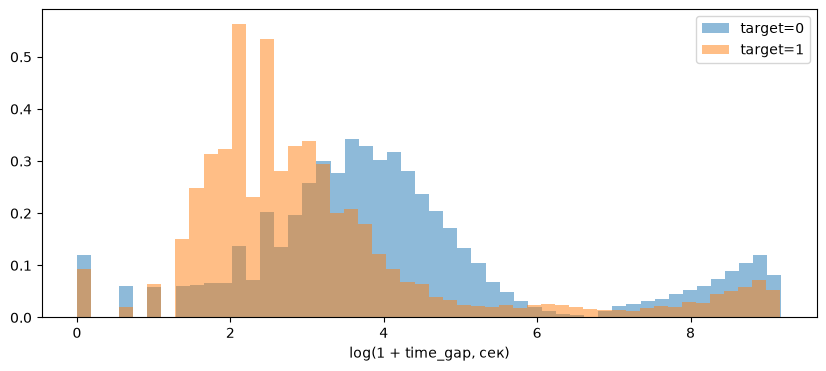

In [85]:
fig, ax = plt.subplots(figsize=(10, 4))
for label, sub in events.groupby('target')['time_gap']:
    #density - нормировка, чтобы смотреть форму распределений, а не на абсолютные знгачения
    # между min and max большой разбро с по сенкудам, на 3-4 порядка, следовательно обернем в log1p
    #lo1p , but not log  - у нас есть min==0 => log(0) = -inf, никак не сработаемся
    ax.hist(np.log1p(sub.dropna()), bins=50, alpha=0.5, label=f'target={label}', density=True)
ax.legend()
ax.set_xlabel('log(1 + time_gap, сек)')
plt.show()

In [86]:
events.loc[events['target']==1,'time_gap'].value_counts()

time_gap
6.0       1521
5.0       1470
7.0       1465
8.0       1178
4.0       1169
          ... 
5418.0       1
5111.0       1
3387.0       1
1603.0       1
2202.0       1
Name: count, Length: 2463, dtype: int64

что видно по граффику?
- у ботов есть два пика, может ли это быть специальными паузами?
- если есть скрипт, то применяется ли он к разным действиям , платформам и тп?
- а может два вида ботов, а не поведение у всех таковое
- у людей же более планое без явных пиков рапсределение
- различия наблюдатеся именно в log(1 + gap) +- 1.8 и где-то до трех с хвостиком

In [87]:
from scipy.signal import find_peaks

sub_sec_bots = events.loc[events.target == 1, 'time_gap'].dropna()
#пики явно меньше 60 
# sub_sec_bots = sub_sec_bots[sub_sec_bots <= 60]                     
counts = sub_sec_bots.value_counts().sort_index()         

peaks, props = find_peaks(counts.values, prominence=100)
print(counts.index[peaks].tolist(), props['prominences'])

[6.0] [1422.]


In [88]:
sub_sec_people = events.loc[events.target == 0, 'time_gap'].dropna()
# sub_sec_people = sub_sec_people[sub_sec_people <= 60]                     
counts = sub_sec_people.value_counts().sort_index()         

peaks, props = find_peaks(counts.values, prominence=100)
print(counts.index[peaks].tolist(), props['prominences'])

[9.0] [377.]


In [89]:
1422/60

23.7

In [90]:
#что происходит за это время, может меняют платформы
check_platforms = events[['platform', 'cookie_id', 'time_gap']].copy()
check_platforms['prev_platform'] = grouped_by_cookie['platform'].shift()
switched = check_platforms['platform'] != check_platforms['prev_platform']

In [91]:
print("Доля переключений платформы среди гэпов 5-7с:", switched[events.time_gap.between(5,7)].mean())
print("Доля переключений платформы среди гэпов 1400-1450с:", switched[events.time_gap.between(1400,1450)].mean())
print("Базовая доля переключений по всем гэпам:", switched[events.time_gap.notna()].mean())

Доля переключений платформы среди гэпов 5-7с: 0.2570048309178744
Доля переключений платформы среди гэпов 1400-1450с: 0.22839506172839505
Базовая доля переключений по всем гэпам: 0.20645867250260216


#### что получаем из времени
- как оказалось, пик всего один, с хорошей prominence
- ботов у нас мало в выборке, а разница в promninence ОГРОМНАЯ! => боты концентируются вокруг какого-то интервала времени больше чем люди
- подходят для всех, общий паттерн
- везде одинаковое переключение по платформам, не то


##### ПРИЗНАК
для признака попробуем три концепции, какой-то из них может стать признаком
- **медиана на cookie** - разница вообщем между людьми и ботами, может и по отдельности тоже будем хорошо себя показывать
-  **доля time_gap в окне 4-10**, где активная деятельность у ботов
- **std/mean** - коэффициент вариации, насколько резко выступает пик, как помним, у ботов в общем он огромный

In [92]:
time_gap_feature = grouped_by_cookie.agg(
    #meidan по умлочанию пропускает NaN
    median = ('time_gap', lambda s: s.median()),
    #самые первые у нас Nan, поэтому чтобы не искажать оценку dropna
    #если у нас только один предположим захват времени, _> гэпа нет и будет пустой ряд
    # а так было бы 0.0
    gaps_share = ('time_gap', lambda s : s.dropna().between(4,10).mean()),
    #тоже агрегирующие функциии, в которых skipna = True
    variation = ('time_gap', lambda s: s.std()/s.mean()),
    std_gap = ('time_gap', lambda s: s.std()),
    mean = ('time_gap', lambda s: s.mean())
)

In [93]:
time_gap_feature.isna().mean()
# для median, gaps_share необходимо как минимум 2 значения, для существования time_gap
# для std нужно как минимум два TIME_gap -> 3 измерения
# std считает несмещенное выборочное старндартное отклонение, где идет деление на n-1

median        0.022270
gaps_share    0.022270
variation     0.057434
std_gap       0.057434
mean          0.022270
dtype: float64

In [94]:
time_gap_feature = time_gap_feature.merge(train[['cookie_id', 'target']], on='cookie_id')


In [95]:
time_gap_feature.isna().mean()

cookie_id     0.000000
median        0.022270
gaps_share    0.022270
variation     0.057434
std_gap       0.057434
mean          0.022270
target        0.000000
dtype: float64

In [96]:
check_na_gaps = time_gap_feature['variation'].isna()
time_gap_feature.groupby(check_na_gaps)['target'].mean()

variation
False    0.084657
True     0.021978
Name: target, dtype: float64

In [97]:
# посмотрим как доля ботов меняется с изменением каждого признака, поделим qcut
for col in ['median', 'gaps_share', 'variation', 'std_gap', 'mean']:
    print(f"\n CHECKING {col}")
    
    _, bin_edges = pd.qcut(time_gap_feature[col], q=5, duplicates='drop', retbins=True)
    #так как у нас есть большая разница между большой и малой активностью, то мы заполним Nan -> -1
    # чтобы выделить их и в calc_iv grooupby просто не смел эти данные
    #соединяем и добавляем в начало границ -2, которое меньше -1 b меньше любого настоящего
    bin_edges_ext = np.r_[-2, bin_edges]
    filled = time_gap_feature[col].fillna(-1)
    # используем assign чтобы создать копию и трогать оригинал нашего time_gap_feature
    table, iv = calc_iv(time_gap_feature.assign(**{col:filled}), col, 'target', bins=bin_edges_ext)
    print(iv)
    



 CHECKING median
0.9468763161437093

 CHECKING gaps_share
0.42098306297466637

 CHECKING variation
0.5048717961313012

 CHECKING std_gap
0.2323494918140314

 CHECKING mean
0.27234258499190933


In [98]:
time_gap_feature[['median', 'gaps_share', 'variation', 'std_gap']].corr()

,median,gaps_share,variation,std_gap
median,1.000000,-0.117533,-0.211638,0.331822
gaps_share,-0.117533,1.000000,0.299716,-0.128469
variation,-0.211638,0.299716,1.000000,0.227725
std_gap,0.331822,-0.128469,0.227725,1.000000


## FOUND
- если прям малая активность, то с меньшей вероятностью боты
- признаки еще и между собой слабо коррелируют, можно будет скормить модели их все, либо вместе, либо как нибудь еще
- интересные метрики, котоыре можно добавить в будущую таблицу приизнаков

## USER_AGENT analyse
- как мы помним, были тут библиотеки -> зачем кому-то заходить на авито таким образом
- надо понять, какая конкретная аномалия здесь характерна для скриптов

In [99]:
import re
#чаще всего броузеры начинаются с мозилы
is_browser_like = events['user_agent'].str.match(r'^Mozilla/')

In [100]:
non_moz = events.loc[~is_browser_like, 'user_agent'].unique()
print(len(non_moz))

39


In [101]:
non_moz.value_counts()
#Avito/ - > мобильный трафик из самого приложения

Avito/118.0 (Android 11; M2101K6G) okhttp/4.11.0    1
Avito/118.0 (Android 13; SM-A515F) okhttp/4.11.0    1
Avito/122.0 (iPhone; iOS 16.2; Scale/3.00)          1
Avito/122.0 (Android 13; SM-A515F) okhttp/4.11.0    1
Avito/120.0 (Android 11; M2101K6G) okhttp/4.11.0    1
Avito/120.0 (Android 13; M2101K6G) okhttp/4.11.0    1
Avito/118.0 (Android 11; SM-A125F) okhttp/4.11.0    1
Avito/120.0 (Android 12; M2101K6G) okhttp/4.11.0    1
node-fetch/3.3.2                                    1
Avito/118.0 (Android 12; SM-A125F) okhttp/4.11.0    1
Avito/120.0 (Android 11; SM-A515F) okhttp/4.11.0    1
Avito/120.0 (Android 11; SM-A125F) okhttp/4.11.0    1
Avito/118.0 (Android 13; SM-A125F) okhttp/4.11.0    1
Avito/122.0 (Android 11; M2101K6G) okhttp/4.11.0    1
Avito/122.0 (Android 11; SM-A515F) okhttp/4.11.0    1
Avito/122.0 (Android 12; SM-A515F) okhttp/4.11.0    1
Avito/118.0 (Android 12; M2101K6G) okhttp/4.11.0    1
Avito/122.0 (Android 13; M2101K6G) okhttp/4.11.0    1
python-requests/2.31.0      

In [102]:
avito_users = events.loc[events['user_agent'].str.startswith('Avito'), 'user_agent'].unique()
avito_users

<ArrowStringArray>
['Avito/118.0 (Android 11; M2101K6G) okhttp/4.11.0',
 'Avito/118.0 (Android 13; SM-A515F) okhttp/4.11.0',
       'Avito/122.0 (iPhone; iOS 16.2; Scale/3.00)',
 'Avito/122.0 (Android 13; SM-A515F) okhttp/4.11.0',
 'Avito/120.0 (Android 11; M2101K6G) okhttp/4.11.0',
 'Avito/120.0 (Android 13; M2101K6G) okhttp/4.11.0',
 'Avito/118.0 (Android 11; SM-A125F) okhttp/4.11.0',
 'Avito/120.0 (Android 12; M2101K6G) okhttp/4.11.0',
 'Avito/118.0 (Android 12; SM-A125F) okhttp/4.11.0',
 'Avito/120.0 (Android 11; SM-A515F) okhttp/4.11.0',
 'Avito/120.0 (Android 11; SM-A125F) okhttp/4.11.0',
 'Avito/118.0 (Android 13; SM-A125F) okhttp/4.11.0',
 'Avito/122.0 (Android 11; M2101K6G) okhttp/4.11.0',
 'Avito/122.0 (Android 11; SM-A515F) okhttp/4.11.0',
 'Avito/122.0 (Android 12; SM-A515F) okhttp/4.11.0',
 'Avito/118.0 (Android 12; M2101K6G) okhttp/4.11.0',
 'Avito/122.0 (Android 13; M2101K6G) okhttp/4.11.0',
 'Avito/122.0 (Android 12; M2101K6G) okhttp/4.11.0',
 'Avito/122.0 (Android 11; 

In [103]:
is_suspicious_agents = (
   ( ~events['user_agent'].str.match(r'^Mozilla/')) &
   ( ~events['user_agent'].str.match(r'^Avito/'))
)

In [104]:
events['is_suspicious_agent'] = is_suspicious_agents

In [105]:
susp_agents_by_cookie = events.groupby('cookie_id').agg(
    susp_n = ('is_suspicious_agent', 'sum'),
    susp_mean = ('is_suspicious_agent', 'mean'),
    target = ('target', 'first')
).sort_values('susp_mean', ascending=False).reset_index()

In [106]:
susp_agents_by_cookie.groupby('target')['susp_n'].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,10192.0,0.241170,2.560986,0.0,0.0,0.0,0.0,80.0
1,899.0,1.969967,11.365961,0.0,0.0,0.0,0.0,120.0


In [107]:
susp_agents_by_cookie.groupby('target')['susp_mean'].describe()
#то есть есть люди и боты  у которых 100% подозрительаня вещь
# с одной стороны тут перекат в сторону ботов и по среднему и по максимум,
# однако recall маленький, а precision довольно таки, а у нас recal>=70

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,10192.0,0.015306,0.122773,0.0,0.0,0.0,0.0,1.0
1,899.0,0.048943,0.215870,0.0,0.0,0.0,0.0,1.0


In [108]:
susp_agents_by_cookie[susp_agents_by_cookie['susp_mean']==1.0]['target'].value_counts()
# в сырых значениях люди как будто бы доминируют
#BUT
#156/10192 +- 1.53 из всей выборки людей
#44/899 +- 4.89% - из всей выборки ботов

target
0    156
1     44
Name: count, dtype: int64

In [109]:

full = susp_agents_by_cookie[susp_agents_by_cookie['susp_mean'] == 1.0]
print(full['target'].value_counts()) 

n_per_cookie = events.groupby('cookie_id').size().rename('n').reset_index()
full_with_n = full.merge(n_per_cookie, on='cookie_id')
print(full_with_n.groupby('target')['n'].describe())

target
0    156
1     44
Name: count, dtype: int64
        count      mean        std  min   25%   50%    75%    max
target                                                           
0       156.0  15.75641  13.608049  1.0  6.00  12.0  19.25   80.0
1        44.0  40.25000  33.485245  3.0  8.75  35.0  69.50  120.0


у полностью подоризтельных
- медиана 12 людей
- 35 медиана ботов, что более сущесвтенно чем для людей
- вопрос тот же,  зачем людям библиотеки

In [110]:
#подозрительные люди
susp_humans_only = susp_agents_by_cookie[
    (susp_agents_by_cookie['susp_mean'] == 1) &
    (susp_agents_by_cookie['target']==0)
]
susp_humans_only

,cookie_id,susp_n,susp_mean,target
0,ck_9e4ca7f49354f324,5,1.0,0
1,ck_f39dc83807f3e59c,4,1.0,0
2,ck_da2528d09bf66ab2,4,1.0,0
4,ck_5d746ba53ab28586,19,1.0,0
5,ck_cd572ca63756ad48,10,1.0,0
...,...,...,...,...
194,ck_6fae582d90cf30ee,13,1.0,0
196,ck_d15d67b4158442e8,5,1.0,0
197,ck_57d8b88393ec0654,35,1.0,0
198,ck_69db844f180c939b,14,1.0,0


In [111]:
mask_human_susp = events['cookie_id'].isin(susp_humans_only['cookie_id'])
susbset_susp_humans = events[mask_human_susp]
print("UA-строки:")
print(susbset_susp_humans['user_agent'].value_counts())



UA-строки:
user_agent
curl/8.1.2                             517
Go-http-client/1.1                     508
Scrapy/2.11.0 (+https://scrapy.org)    453
python-urllib3/2.0.7                   341
python-requests/2.31.0                 322
node-fetch/3.3.2                       317
Name: count, dtype: int64


In [112]:
print("\nПлатформа:")
print(susbset_susp_humans['platform'].value_counts())




Платформа:
platform
web        1832
desktop     626
Name: count, dtype: int64


In [113]:
print("\nТип продавца:")
print(susbset_susp_humans['seller_type'].value_counts(dropna=False))



Тип продавца:
seller_type
NaN        950
private    860
pro        648
Name: count, dtype: int64


In [114]:

print("\nТипы событий:")
print(susbset_susp_humans['event_name'].value_counts())



Типы событий:
event_name
item_view               911
search_results_view     762
photo_swipe             306
favorite_add            141
seller_page_view        136
contact_phone_show       76
contact_chat_open        54
login                    49
contact_message_sent     23
Name: count, dtype: int64


In [115]:

print("\nТайминги (гэпы):")
print(susbset_susp_humans['time_gap'].describe())


Тайминги (гэпы):
count    2302.000000
mean      760.044744
std      1946.863951
min         0.000000
25%        21.000000
50%        51.000000
75%       130.000000
max      9109.000000
Name: time_gap, dtype: float64


In [116]:
#bots analyse,-> они похожи по активности на других ботов - проверка
susp_bots_ids = susp_agents_by_cookie[
    (susp_agents_by_cookie['susp_mean'] == 1.0) & (susp_agents_by_cookie['target'] == 1)
]['cookie_id']
print("Боты с подозрительным UA — тайминги:")
print(events[events['cookie_id'].isin(susp_bots_ids)]['time_gap'].describe())

Боты с подозрительным UA — тайминги:
count    1727.000000
mean      362.884192
std      1379.716313
min         0.000000
25%         6.000000
50%        10.000000
75%        20.000000
max      8882.000000
Name: time_gap, dtype: float64


# ИДЕЯ
- скомбинировать активность + susp_mean, потому что они похожи на ботов, но вот например тайминги по своим показателям похожи на общее распредедение для люедй
- таймиги у всех соотносятся со своими типами - ботами и людьми соответсвенно

In [117]:
_, bin_edges_susps = pd.qcut(susp_agents_by_cookie['susp_mean'],
                              q=5, duplicates='drop', retbins=True)
#проблема втом, что у нас то большинство то НЕподорительностью, все схлопнулось
table, iv_susp = calc_iv(susp_agents_by_cookie, 'susp_mean', 'target', bins=bin_edges_susps)
print(iv_susp)

0.0


In [118]:
table, iv_susp = calc_iv(susp_agents_by_cookie, 'susp_mean', 'target')
print(iv_susp)
#маловато, но моеждм проверить как и с курсором, может усиливается вне мобилок

0.040267740436056146


In [119]:
susp_agents_by_cookie = susp_agents_by_cookie.merge(cookie_platforms.reset_index()[['platforms', 'cookie_id']], on='cookie_id')
susp_agents_by_cookie

,cookie_id,susp_n,susp_mean,target,platforms
0,ck_9e4ca7f49354f324,5,1.0,0,desktop+web
1,ck_f39dc83807f3e59c,4,1.0,0,web
2,ck_da2528d09bf66ab2,4,1.0,0,desktop+web
3,ck_2b2541cd975d18a7,53,1.0,1,desktop+web
4,ck_5d746ba53ab28586,19,1.0,0,desktop+web
...,...,...,...,...,...
11086,ck_55cbaae6a01e62e3,0,0.0,1,desktop+web
11087,ck_55d2d41acf9d1dad,0,0.0,0,android
11088,ck_55d5acf5e28870c2,0,0.0,0,desktop+web
11089,ck_55d734433f012efa,0,0.0,0,desktop+web


In [120]:
mask_dw_suso = susp_agents_by_cookie[susp_agents_by_cookie['platforms']=='desktop+web']
table, iv_susp_dw = calc_iv(mask_dw_suso, 'susp_mean', 'target')
print(iv_susp_dw) #такой же глоабльный почти

0.0368915131463758


In [121]:
mask_web_suso = susp_agents_by_cookie[susp_agents_by_cookie['platforms']=='web']
table, iv_susp_web = calc_iv(mask_web_suso, 'susp_mean', 'target')
print(iv_susp_web) #но только таких у нас мало вообще по численности

0.2796263557182763


проверять будем с таймингом susp_mean

# Search_query and page

In [122]:
all_events = pd.read_csv('data/events.csv.gz', parse_dates=['event_ts'])
test_events = all_events.merge(test, on='cookie_id')
test_events = test_events[(test_events.event_ts >= test_events.window_start_ts) & (test_events.event_ts < test_events.window_end_ts)]

In [123]:
test_events['platform'] = (test_events['platform'].str.lower().str.strip().map(mapping_platform))

In [124]:
print("УНИКальные элементы")
for col in test_events.columns:
    print(f"{col} :  {test_events[col].nunique()}")

УНИКальные элементы
cookie_id :  4909
event_ts :  80974
eid :  9
event_name :  9
platform :  4
user_agent :  148
item_id :  30902
item_category :  15
item_location :  40
seller_type :  2
search_query :  120
search_page :  38
pointer_x :  1921
pointer_y :  1081
cookie_created_at :  4908
window_start_ts :  7
window_end_ts :  7


In [125]:
print(test_events.isna().mean().round(3))

cookie_id            0.000
event_ts             0.000
eid                  0.000
event_name           0.000
platform             0.000
user_agent           0.000
item_id              0.333
item_category        0.076
item_location        0.050
seller_type          0.392
search_query         0.687
search_page          0.687
pointer_x            0.672
pointer_y            0.672
cookie_created_at    0.000
window_start_ts      0.000
window_end_ts        0.000
dtype: float64


In [126]:
events['search_query'].nunique()

120

In [127]:
test_events[test_events['search_query'].isin(events['search_query'].unique())]['search_query'].nunique()

120

In [128]:
for event in events['event_name'].unique():
    cookie_event_activity = events.groupby('cookie_id').agg(
        target = ('target', 'first'),
        search_query_n = ('event_name', lambda s: (s==event).sum()),
        total_n=('event_name', 'size'),
    ).reset_index()

    #так как боты активнее в принцпие людей, надо нормализовать для сравнения
    cookie_event_activity['search_share'] = cookie_event_activity['search_query_n'] / cookie_event_activity['total_n']
    print("\n ", event)
    print(cookie_event_activity.groupby('target')['search_share'].describe())


  search_results_view
          count      mean       std  min       25%       50%       75%  max
target                                                                     
0       10192.0  0.308472  0.177002  0.0  0.204335  0.300000  0.400000  1.0
1         899.0  0.331261  0.142211  0.0  0.250000  0.333333  0.418011  0.9

  photo_swipe
          count      mean       std  min  25%       50%       75%       max
target                                                                     
0       10192.0  0.127041  0.129939  0.0  0.0  0.111111  0.181818  1.000000
1         899.0  0.078164  0.083506  0.0  0.0  0.062500  0.111111  0.666667

  item_view
          count      mean       std  min       25%       50%       75%  max
target                                                                     
0       10192.0  0.364250  0.185132  0.0  0.259259  0.357143  0.461538  1.0
1         899.0  0.424916  0.153326  0.0  0.333333  0.428571  0.500000  1.0

  seller_page_view
          count  

In [129]:
event_name_influence = events.groupby('cookie_id').agg(
    target=('target', 'first'),
    total_n=('event_name', 'size'),
    photo_swipe_n=('event_name', lambda s: (s == 'photo_swipe').sum()),
    favorite_add_n=('event_name', lambda s: (s == 'favorite_add').sum()),
    login_n=('event_name', lambda s: (s == 'login').sum()),
).reset_index()



In [130]:
event_name_influence['photo_swipe_share'] = event_name_influence['photo_swipe_n'] / event_name_influence['total_n']
event_name_influence['favorite_add_share'] = event_name_influence['favorite_add_n'] / event_name_influence['total_n']
event_name_influence['login_share'] = event_name_influence['login_n'] / event_name_influence['total_n']

In [131]:
for col in ['photo_swipe_share','favorite_add_share', 'login_share']:
    _, bin_edges_cols = pd.qcut(event_name_influence[col], q=5, duplicates='drop',   retbins=True)
    table, cols_iv = calc_iv(event_name_influence, col, 'target', bins=bin_edges_cols)
    print(f"{col}: {cols_iv}")

photo_swipe_share: 0.2844955899596612
favorite_add_share: 0.23547319614317944
login_share: 0.09988510359825896


## Возраст куки
- есть ли разница в том,  сколько куки существует

In [132]:
cookie_live = train.copy()
cookie_live['cookie_age'] = (cookie_live['window_start_ts'] - cookie_live['cookie_created_at']).dt.total_seconds()

In [133]:
print("PEOPLE")
print(cookie_live.loc[cookie_live.target==0, 'cookie_age'].describe())

print("\nBOTS")
print(cookie_live.loc[cookie_live.target==1, 'cookie_age'].describe())

PEOPLE
count    1.019200e+04
mean     6.385685e+06
std      5.786291e+06
min      1.253000e+03
25%      1.628660e+06
50%      5.337996e+06
75%      9.542569e+06
max      3.881821e+07
Name: cookie_age, dtype: float64

BOTS
count    8.990000e+02
mean     4.209962e+06
std      5.425548e+06
min      1.068000e+03
25%      8.151800e+04
50%      1.638870e+06
75%      7.210334e+06
max      3.125641e+07
Name: cookie_age, dtype: float64


что мы видим
- медиана различается и 25%
- боты чаще всего новые куки

In [134]:
#check cookie_age
_, bin_edges_age = pd.qcut(cookie_live['cookie_age'], duplicates='drop', q = 5, retbins=True)
table, res = calc_iv(cookie_live,'cookie_age', 'target', bins=bin_edges_age)
print(res)

0.28868629609025326


# ДОБАВЛЯЕМ
- age

## MEan activity

In [135]:
events.groupby('cookie_id')['event_ts'].mean().dt.hour

cookie_id
ck_000c95f1408dcb00    18
ck_000e8c52636e3bec     7
ck_0010e31baa4a1fb7    17
ck_0010ec3874fb5378    11
ck_001722063b94cae0    18
                       ..
ck_ffe2bdd663cea9ac    13
ck_ffe648839179d098     8
ck_ffee36a37e2532f5    16
ck_fff88a7920fd0fb6     5
ck_fffa4b3ab0203fcf    18
Name: event_ts, Length: 11091, dtype: int32

In [136]:
events['mean_activity'] = events.groupby('cookie_id')['event_ts'].transform('mean').dt.hour

In [137]:
events['mean_activity'].isna().sum()

np.int64(0)

In [138]:
mean_act_check = events.groupby('cookie_id').agg(
    mean_activity=('mean_activity', 'first'),
    target = ('target', 'first')
).reset_index()
print("PEOPLE")
print(mean_act_check.loc[mean_act_check.target==0, 'mean_activity'].describe())

print("BOTS")
print(mean_act_check.loc[mean_act_check.target==1, 'mean_activity'].describe())

PEOPLE
count    10192.000000
mean        14.133438
std          6.313379
min          0.000000
25%          9.000000
50%         15.000000
75%         20.000000
max         23.000000
Name: mean_activity, dtype: float64
BOTS
count    899.000000
mean      12.857620
std        6.956577
min        0.000000
25%        7.000000
50%       13.000000
75%       19.000000
max       23.000000
Name: mean_activity, dtype: float64


In [139]:
_, bins_mean_act = pd.qcut(mean_act_check['mean_activity'], q=5, retbins=True, duplicates='drop')
table, iv_mean_act = calc_iv(mean_act_check, 'mean_activity', 'target', bins_mean_act)
print(iv_mean_act)

0.04646717730843698


In [140]:
bins_mean_act

array([ 0.,  8., 13., 17., 20., 23.])

## МОжет быть, но меньше 20%
- mean_activity

## Провека типов items
- может быть люди имеют более меньший диапазон интереса

In [141]:
events['item_category_count'] = events.groupby('cookie_id')['item_category'].transform('nunique')

In [142]:
item_cat_check = events.groupby('cookie_id').agg(
    item_cat_count = ('item_category_count', 'first'),
    target=('target', 'first')
).reset_index()
print("PEOPLE")
print(item_cat_check.loc[item_cat_check.target==0, 'item_cat_count'].describe())

print("\nBOTS")
print(item_cat_check.loc[item_cat_check.target==1, 'item_cat_count'].describe())

PEOPLE
count    10192.000000
mean         2.281201
std          1.257226
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          8.000000
Name: item_cat_count, dtype: float64

BOTS
count    899.000000
mean       1.787542
std        0.814963
min        0.000000
25%        1.000000
50%        2.000000
75%        2.000000
max        6.000000
Name: item_cat_count, dtype: float64


In [143]:
_, bins_item_cat_count = pd.qcut(item_cat_check[ 'item_cat_count'], q=5, retbins=True, duplicates='drop')
table, iv_item_cat_count = calc_iv(item_cat_check, 'item_cat_count', 'target', bins=bins_item_cat_count)
print(iv_item_cat_count)

0.36400113333171913


In [144]:
bins_item_cat_count

array([0., 1., 2., 3., 8.])

## Добавляем
- item_category_count

## Check search_page
- не лень ли людя ходить до максимального 63 страниц в  глубину
- а также разнообразие search_query

In [145]:
events['search_depth'] = events.groupby('cookie_id')['search_page'].transform('max')
events['num_query'] = events.groupby('cookie_id')['search_query'].transform('nunique')


In [146]:
events['search_depth'].isna().sum()

np.int64(3480)

In [147]:
search_depth_check = events.groupby('cookie_id').agg(
    target = ('target', 'first'),
    depth = ('search_depth', 'first')
).reset_index()
print("PEOPLE")
print(search_depth_check.loc[search_depth_check.target==0, 'depth'].describe())

print("\nBOTS")
print(search_depth_check.loc[search_depth_check.target==1, 'depth'].describe())

PEOPLE
count    9308.000000
mean        4.415664
std         3.204548
min         1.000000
25%         2.000000
50%         4.000000
75%         6.000000
max        33.000000
Name: depth, dtype: float64

BOTS
count    862.000000
mean       9.299304
std        8.138949
min        1.000000
25%        3.000000
50%        7.000000
75%       12.000000
max       63.000000
Name: depth, dtype: float64


есть проблема, есть nan, так как людей и ботов меньше, чем их в выборке

In [148]:
search_depth_check['depth'].isna().sum(0)

/tmp/ipykernel_4791/4048609767.py:1: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  search_depth_check['depth'].isna().sum(0)


np.int64(921)

In [149]:
_, bins_search_depth = pd.qcut(search_depth_check['depth'], q=5, duplicates='drop', retbins=True)
bins_search_ext = np.r_[-2, bins_search_depth]
filled_search_depth_check = search_depth_check['depth'].fillna(-1)

In [150]:
table, iv_search_depth = calc_iv(search_depth_check.assign(depth=filled_search_depth_check), 'depth', 'target', bins=bins_search_ext)
print(iv_search_depth)

0.5421486092042062


In [151]:
bins_search_depth

array([ 1.,  2.,  3.,  5.,  7., 63.])

In [152]:
query_dif_check = events.groupby('cookie_id').agg(
    target = ('target', 'first'),
num_query = ('num_query', 'first')
).reset_index()
print("PEOPLE")
print(query_dif_check.loc[query_dif_check.target==0, 'num_query'].describe())

print("\nBOTS")
print(query_dif_check.loc[query_dif_check.target==1, 'num_query'].describe())

PEOPLE
count    10192.000000
mean         3.789835
std          3.200398
min          0.000000
25%          1.000000
50%          3.000000
75%          5.000000
max         29.000000
Name: num_query, dtype: float64

BOTS
count    899.000000
mean       4.758621
std        3.142606
min        0.000000
25%        2.000000
50%        4.000000
75%        7.000000
max       17.000000
Name: num_query, dtype: float64


In [153]:
_, bins_search_num = pd.qcut(query_dif_check['num_query'], q=5, duplicates='drop', retbins=True)
table, iv_search_num = calc_iv(query_dif_check, 'num_query', 'target', bins=bins_search_num)
print(iv_search_num)

0.1427790570063654


In [154]:
bins_search_num

array([ 0.,  1.,  2.,  4.,  6., 29.])

## Item _location and seller type
- уже последние для анализа

In [155]:
events['item_location'].nunique()

40

In [156]:
events['seller_type'].isna().sum()

np.int64(77658)

In [157]:
events['item_location'].isna().sum()
#но так как мы будем считьать nunique - не помешает
#проблема будет с seller_type потому что там были isna

np.int64(9826)

In [158]:
events['item_location_count'] = events.groupby('cookie_id')['item_location'].transform('nunique')


In [159]:
item_loc_count_check = events.groupby('cookie_id').agg(
    target = ('target', 'first'),
    num_loc = ('item_location_count', 'first')
).reset_index()

print("PEOPLE")
print(item_loc_count_check.loc[item_loc_count_check.target==0, 'num_loc'].describe())

print("\nBOTS")
print(item_loc_count_check.loc[item_loc_count_check.target==1, 'num_loc'].describe())

PEOPLE
count    10192.000000
mean         5.881868
std          4.637013
min          0.000000
25%          2.000000
50%          5.000000
75%          8.000000
max         30.000000
Name: num_loc, dtype: float64

BOTS
count    899.000000
mean       9.789766
std        6.068215
min        1.000000
25%        5.000000
50%        8.000000
75%       14.000000
max       31.000000
Name: num_loc, dtype: float64


In [160]:
item_loc_count_check['num_loc'].isna().sum()
#для тех, у кого был бы весь Nan -> 0

np.int64(0)

In [161]:
_, bins_loc_count = pd.qcut(item_loc_count_check['num_loc'], q=5, duplicates='drop', retbins=True)
table, iv_loc_count= calc_iv(item_loc_count_check, 'num_loc', 'target', bins=bins_loc_count)
print(iv_loc_count)

0.6044428174200278


In [162]:
bins_loc_count

array([ 0.,  2.,  4.,  6., 10., 31.])

In [163]:
#отбросим Nan, чтобы доля считалась среди тех, у кого есть
# если будут те, у которых вообще не буедт, то тогда как и раньше отдельнная категория  в бинах = -2 до 0
events['pro_seller_share'] = events.groupby('cookie_id')['seller_type'].transform(
    lambda s: (s.dropna() == 'pro').mean()
)

In [164]:
pro_seller_check = events.groupby('cookie_id').agg(
    target = ('target', 'first'),
    pro_seller = ('pro_seller_share', 'first')
).reset_index()

print("PEOPLE")
print(pro_seller_check.loc[pro_seller_check.target==0, 'pro_seller'].describe())

print("\nBOTS")
print(pro_seller_check.loc[pro_seller_check.target==1, 'pro_seller'].describe())

PEOPLE
count    9950.000000
mean        0.410709
std         0.261914
min         0.000000
25%         0.250000
50%         0.400000
75%         0.555556
max         1.000000
Name: pro_seller, dtype: float64

BOTS
count    898.000000
mean       0.452716
std        0.211942
min        0.000000
25%        0.333333
50%        0.449138
75%        0.571429
max        1.000000
Name: pro_seller, dtype: float64


In [165]:
pro_seller_check['pro_seller'].isna().sum()

np.int64(243)

In [166]:
_, bin_pro_seller = pd.qcut(pro_seller_check['pro_seller'], q=5, duplicates='drop', retbins=True)
bins_pro_seller_ext = np.r_[-2, bin_pro_seller]
filled_pro_seller= pro_seller_check['pro_seller'].fillna(-1)

In [167]:
bins_pro_seller_ext

array([-2.        ,  0.        ,  0.2       ,  0.35714286,  0.475     ,
        0.6       ,  1.        ])

In [168]:
table, iv_pro_seller = calc_iv(pro_seller_check.assign(pro_seller=filled_pro_seller), 'pro_seller', 'target', bins=bins_pro_seller_ext)
print(iv_pro_seller)

0.15293645301253697


#### После сабмита было получено 0.25  - мало
что можно проверить
- разброс pointers, может бот будет как-то скакать? captcha нет, но не зря ж ее придумали
- хорошо себя показала search_page_max, но может чуть другую метрику сделать - mean/median
- такое же рассуждение с search_query - попробовать оценивания
- был посчитан median_gap, но может проверить не только это, но и саму скорость, может будут коррелировать, но попробовать стоит
- был посчитан вклад одного какого-то event_name, но может стоит посичтатть какую-то общую картину

In [169]:
pointers_std_metric = events.groupby('cookie_id').agg(
    target = ('target', 'first'),
    pointer_x_std = ('pointer_x', lambda s: s.dropna().std()),
    pointer_y_std = ('pointer_y', lambda s: s.dropna().std())
).reset_index()
pointers_std_metric
# много Nan, не хвататет данных для посчтитки некоторым

,cookie_id,target,pointer_x_std,pointer_y_std
0,ck_000c95f1408dcb00,0,494.980875,338.074640
1,ck_000e8c52636e3bec,0,561.544146,277.719426
2,ck_0010e31baa4a1fb7,0,501.890941,361.434157
3,ck_0010ec3874fb5378,0,NaN,NaN
4,ck_001722063b94cae0,0,NaN,NaN
...,...,...,...,...
11086,ck_ffe2bdd663cea9ac,0,NaN,NaN
11087,ck_ffe648839179d098,0,NaN,NaN
11088,ck_ffee36a37e2532f5,0,NaN,NaN
11089,ck_fff88a7920fd0fb6,0,NaN,NaN


In [170]:

print("PEOPLE")
print(pointers_std_metric.loc[pointers_std_metric.target==0, 'pointer_x_std'].describe())

print("\nBOTS")
print(pointers_std_metric.loc[pointers_std_metric.target==1, 'pointer_x_std'].describe())

PEOPLE
count    3674.000000
mean      540.923594
std       135.813795
min         0.000000
25%       490.662946
50%       552.050024
75%       607.619287
max      1247.336362
Name: pointer_x_std, dtype: float64

BOTS
count    250.000000
mean     219.609624
std      132.261472
min        8.485281
25%      125.435212
50%      200.551441
75%      283.219196
max      813.596337
Name: pointer_x_std, dtype: float64


In [171]:

print("PEOPLE")
print(pointers_std_metric.loc[pointers_std_metric.target==0, 'pointer_y_std'].describe())

print("\nBOTS")
print(pointers_std_metric.loc[pointers_std_metric.target==1, 'pointer_y_std'].describe())

PEOPLE
count    3674.000000
mean      300.348909
std        76.033658
min         0.000000
25%       271.090318
50%       308.072691
75%       338.986117
max       696.500179
Name: pointer_y_std, dtype: float64

BOTS
count    250.000000
mean     200.276529
std       95.217350
min       11.330065
25%      132.533675
50%      200.969948
75%      264.497898
max      480.373466
Name: pointer_y_std, dtype: float64


In [172]:
_, bins_pointer_x_bons = pd.qcut(pointers_std_metric['pointer_x_std'], q=5, duplicates='drop', retbins=True)
bins_pointer_x_bons_ext = np.r_[-2, bins_pointer_x_bons]
filled_pointers_std_x = pointers_std_metric['pointer_x_std'].fillna(-1)

table, iv_pointer_x = calc_iv(pointers_std_metric.assign(pointer_x_std = filled_pointers_std_x), 'pointer_x_std', 'target', bins = bins_pointer_x_bons_ext)
iv_pointer_x

np.float64(1.226759729295414)

In [173]:
bins_pointer_x_bons_ext

array([  -2.        ,    0.        ,  440.03099986,  521.51788594,
        566.02887619,  619.55792986, 1247.33636201])

In [174]:
_, bins_pointer_y_bons = pd.qcut(pointers_std_metric['pointer_y_std'], q=5, duplicates='drop', retbins=True)
bins_pointer_y_bons_ext = np.r_[-2, bins_pointer_y_bons]
filled_pointers_std_y = pointers_std_metric['pointer_y_std'].fillna(-1)

table, iv_pointer_y = calc_iv(pointers_std_metric.assign(pointer_y_std = filled_pointers_std_y), 
                              'pointer_y_std', 'target', bins = bins_pointer_y_bons_ext)
iv_pointer_y

np.float64(0.4856595217166244)

In [175]:
bins_pointer_y_bons_ext

array([ -2.        ,   0.        , 246.73450867, 291.45196066,
       317.09479614, 345.83250171, 696.50017947])

про поинтеры
- очень полезная информация
- особенно по оси y

In [176]:
pages_metrics = events.groupby('cookie_id').agg(
    s_page_mean = ('search_page',lambda s: s.mean() ),
    target=('target', 'first')
).reset_index()
pages_metrics['s_page_mean'].isna().sum()

np.int64(921)

In [177]:

print("PEOPLE")
print(pages_metrics.loc[pages_metrics.target==0, 's_page_mean'].describe())

print("\nBOTS")
print(pages_metrics.loc[pages_metrics.target==1, 's_page_mean'].describe())

PEOPLE
count    9308.000000
mean        2.314816
std         1.120822
min         1.000000
25%         1.500000
50%         2.000000
75%         3.000000
max        13.000000
Name: s_page_mean, dtype: float64

BOTS
count    862.000000
mean       3.589489
std        1.870409
min        1.000000
25%        2.129464
50%        3.190909
75%        4.666667
max       12.333333
Name: s_page_mean, dtype: float64


In [178]:
_, bins_pointer_pages_mean = pd.qcut(pages_metrics['s_page_mean'], q=5, duplicates='drop', retbins=True)
bins_pointer_pages_mean_ext = np.r_[-2, bins_pointer_pages_mean]
filled_s_page_mean = pages_metrics['s_page_mean'].fillna(-1)

table, iv_page_mean = calc_iv(pages_metrics.assign(s_page_mean = filled_s_page_mean), 
                              's_page_mean', 'target', bins = bins_pointer_pages_mean_ext)
iv_page_mean
#тоже явно не плохо
# но на сколько она не коррелирует с search_page_max

np.float64(0.5684084626109922)

In [179]:
depth_mean_corr = search_depth_check.merge(pages_metrics[['cookie_id', 's_page_mean']],on='cookie_id')
depth_mean_corr[['s_page_mean', 'depth']].corr()
#довольнло таки большая, надо будет выбрать одну скорее всего

,s_page_mean,depth
s_page_mean,1.00000,0.79596
depth,0.79596,1.00000


search_page_mean
- имеет хороший также результат, но большая корреляция с search_page_depth
- скорее придется выбрать одну из них

In [180]:
#чтобы посчитать активность, и она не была как-то смещена
# то , можно исплоьзовать cookie_age и n_events/cookie_age - так будет реальная оценка того, 
# как она была активна относительно своего возраста
# просо n_events показали себя средне, но может быть поулчиться улучшить эффект

# тут точно нужно будет заменить , если будет лучшеум
n_events_per_cookie= events.groupby('cookie_id').agg(
    target=('target', 'first'),
    n_events = ('event_name', 'size')
).reset_index()
n_events_per_cookie.isna().sum()

cookie_id    0
target       0
n_events     0
dtype: int64

In [181]:
n_events_per_cookie = n_events_per_cookie.merge(cookie_live[['cookie_id', 'cookie_age']], on='cookie_id')


In [182]:
n_events_per_cookie['events_per_hour_age'] = n_events_per_cookie['n_events'] / n_events_per_cookie['cookie_age']
n_events_per_cookie

,cookie_id,target,n_events,cookie_age,events_per_hour_age
0,ck_000c95f1408dcb00,0,16,20127782.0,7.949212e-07
1,ck_000e8c52636e3bec,0,34,2201485.0,1.544412e-05
2,ck_0010e31baa4a1fb7,0,16,7146582.0,2.238832e-06
3,ck_0010ec3874fb5378,0,74,8846946.0,8.364468e-06
4,ck_001722063b94cae0,0,15,57783.0,2.595919e-04
...,...,...,...,...,...
11086,ck_ffe2bdd663cea9ac,0,32,4907218.0,6.521006e-06
11087,ck_ffe648839179d098,0,28,4006452.0,6.988727e-06
11088,ck_ffee36a37e2532f5,0,81,9622438.0,8.417825e-06
11089,ck_fff88a7920fd0fb6,0,11,5054074.0,2.176462e-06


In [183]:
print("PEOPLE")
print(n_events_per_cookie.loc[n_events_per_cookie.target==0, 'events_per_hour_age'].describe())

print("\nBOTS")
print(n_events_per_cookie.loc[n_events_per_cookie.target==1, 'events_per_hour_age'].describe())

PEOPLE
count    1.019200e+04
mean     8.494791e-05
std      5.187073e-04
min      3.341153e-08
25%      9.944575e-07
50%      2.625918e-06
75%      1.169478e-05
max      3.332113e-02
Name: events_per_hour_age, dtype: float64

BOTS
count    8.990000e+02
mean     3.606571e-04
std      1.350746e-03
min      1.022575e-07
25%      2.853071e-06
50%      2.028863e-05
75%      2.611089e-04
max      2.977044e-02
Name: events_per_hour_age, dtype: float64


In [184]:
_, bins_events_per_hour = pd.qcut(n_events_per_cookie['events_per_hour_age'], q=5, duplicates='drop', retbins=True)
table, iv_events_per_hour= calc_iv(n_events_per_cookie, 'events_per_hour_age', 'target', bins=bins_events_per_hour)
iv_events_per_hour

np.float64(0.48350774649778583)

In [185]:
bins_events_per_hour

array([3.34115341e-08, 8.42359922e-07, 1.95400970e-06, 4.56117603e-06,
       4.36141024e-05, 3.33211278e-02])

events_per_hour_age - тоже довольно таки сильный, уберем n_events и постави этом

In [186]:
# посчитаем разнообразие тем
# в деревьях есть мера неопределенности с помощью энтропии
# показывает, насколь в листе неоднозначный результат
# здесь для тем можно ее также использовать
# насколько сфокусирована кука на какой-то теме
def entropy(counts):
    total = counts.sum()
    if total <= 0:
        return 0.0
    p = counts[counts > 0] / total          
    return float(-(p * np.log2(p)).sum())

In [187]:
#ВАЖЕН ПОРЯДОКб сначал сcookie_id
cookie_with_event = events.groupby(['cookie_id', 'event_name']).size().unstack(fill_value = 0)
#если с каким-то нет записей, пусть будет 0
entr_per_cookie = cookie_with_event.apply(lambda row: entropy(row.values), axis=1)


In [188]:
entr_per_cookie = entr_per_cookie.rename('events_entropy').reset_index()
entr_per_cookie = entr_per_cookie.merge(train[['target', 'cookie_id']], on='cookie_id')
entr_per_cookie

,cookie_id,events_entropy,target
0,ck_000c95f1408dcb00,1.324460,0
1,ck_000e8c52636e3bec,2.412533,0
2,ck_0010e31baa4a1fb7,2.146782,0
3,ck_0010ec3874fb5378,2.195167,0
4,ck_001722063b94cae0,1.532915,0
...,...,...,...
11086,ck_ffe2bdd663cea9ac,2.726410,0
11087,ck_ffe648839179d098,2.537752,0
11088,ck_ffee36a37e2532f5,2.313383,0
11089,ck_fff88a7920fd0fb6,1.095795,0


In [189]:
_, bins_entropy = pd.qcut(entr_per_cookie['events_entropy'], q=5, duplicates='drop', retbins=True)
table, iv_events_entropy= calc_iv(entr_per_cookie, 'events_entropy', 'target', bins=bins_entropy)
iv_events_entropy
#слабенько, но попробуем

np.float64(0.11770666380622782)

In [190]:
# так как в tests.ipynb решено проверять группы, добавим того, чего не быо
# -> item_id
# хорошо себя показали item_cat nunique
# теперь с item_id
item_id_count = events.groupby('cookie_id').agg(
    target = ('target', 'first'),
    item_id_count = ('item_id', 'nunique')
).reset_index()

In [191]:
("PEOPLE")
print(item_id_count.loc[item_id_count.target==0, 'item_id_count'].describe())

print("\nBOTS")
print(item_id_count.loc[item_id_count.target==1, 'item_id_count'].describe())

count    10192.000000
mean         8.917190
std          9.018032
min          0.000000
25%          3.000000
50%          6.000000
75%         12.000000
max         80.000000
Name: item_id_count, dtype: float64

BOTS
count    899.000000
mean      13.779755
std       10.983506
min        1.000000
25%        6.000000
50%       10.000000
75%       18.000000
max       70.000000
Name: item_id_count, dtype: float64


In [192]:
#для групп лучше добавим nunique по seller_type, а не так какк ыбло seller_pro
# собтвенно, pro, не pro, там вообще NaN есть
seller_type_metric = events.groupby('cookie_id').agg(
    target=('target', 'first'),
    seller_type_count = ('seller_type', 'nunique')
).reset_index()

In [193]:
("PEOPLE")
print(seller_type_metric.loc[seller_type_metric.target==0, 'seller_type_count'].describe())

print("\nBOTS")
print(seller_type_metric.loc[seller_type_metric.target==1, 'seller_type_count'].describe())
#выглядит не супер, но проверяем все группы!!!

count    10192.000000
mean         1.757064
std          0.481071
min          0.000000
25%          2.000000
50%          2.000000
75%          2.000000
max          2.000000
Name: seller_type_count, dtype: float64

BOTS
count    899.000000
mean       1.912125
std        0.287175
min        0.000000
25%        2.000000
50%        2.000000
75%        2.000000
max        2.000000
Name: seller_type_count, dtype: float64


In [194]:
#так можно пройтись по всем остальным, также с платформами
platform_metric = events.groupby('cookie_id').agg(
    target=('target', 'first'),
    platform_count = ('platform', 'nunique')
).reset_index()

In [195]:
("PEOPLE")
print(platform_metric.loc[platform_metric.target==0, 'platform_count'].describe())

print("\nBOTS")
print(platform_metric.loc[platform_metric.target==1, 'platform_count'].describe())
#выглядит отвратиельно

count    10192.000000
mean         1.456436
std          0.498123
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          2.000000
Name: platform_count, dtype: float64

BOTS
count    899.000000
mean       1.630701
std        0.482884
min        1.000000
25%        1.000000
50%        2.000000
75%        2.000000
max        2.000000
Name: platform_count, dtype: float64


In [196]:
# мало уникальных значений, не режим
table, iv_plat = calc_iv(platform_metric, 'platform_count', 'target')
print(iv_plat)
#и это не ноль, удивительно, а с деревьями может езе и порешает что нибудь

0.12371377518500584


In [197]:
event_counts = events.groupby(['cookie_id', 'event_name']).size().unstack(fill_value=0)
event_shares = event_counts.div(event_counts.sum(axis=1), axis=0).add_suffix('_share')
event_counts_named = event_counts.add_suffix('_count')

event_stats = event_counts_named.join(event_shares).reset_index()
event_stats = event_stats.merge(train[['cookie_id', 'target']], on='cookie_id')

stat_cols = [c for c in event_stats.columns if c.endswith('_share') or c.endswith('_count')]

for col in stat_cols:
    if event_stats[col].nunique() <= 5:
        table, iv = calc_iv(event_stats, col, 'target')
    else:
        _, bins = pd.qcut(event_stats[col], q=5, duplicates='drop', retbins=True)
        table, iv = calc_iv(event_stats, col, 'target', bins=bins)
    print(f'{col}: IV={iv:.4f}')

contact_chat_open_count: IV=0.0087
contact_message_sent_count: IV=0.0000
contact_phone_show_count: IV=0.0097
favorite_add_count: IV=0.0496
item_view_count: IV=0.4037
login_count: IV=0.0324
photo_swipe_count: IV=0.0017
search_results_view_count: IV=0.3123
seller_page_view_count: IV=0.2535
contact_chat_open_share: IV=0.0000
contact_message_sent_share: IV=0.0000
contact_phone_show_share: IV=0.0000
favorite_add_share: IV=0.2355
item_view_share: IV=0.2034
login_share: IV=0.0999
photo_swipe_share: IV=0.2845
search_results_view_share: IV=0.1028
seller_page_view_share: IV=0.0503


In [198]:
#к аквтиности можно добавить - не уникальных запросов, а именно что сколько вообще запросов
n_query = events.groupby('cookie_id').agg(
    target=('target', 'first'),
    n_query = ('search_query', 'size')
).reset_index()

("PEOPLE")
print(n_query.loc[n_query.target==0, 'n_query'].describe())

print("\nBOTS")
print(n_query.loc[n_query.target==1, 'n_query'].describe())
#различия есть!

count    10192.000000
mean        16.869015
std         16.173297
min          1.000000
25%          6.000000
50%         12.000000
75%         22.000000
max        140.000000
Name: n_query, dtype: float64

BOTS
count    899.000000
mean      29.484983
std       27.515182
min        1.000000
25%       11.000000
50%       20.000000
75%       38.000000
max      169.000000
Name: n_query, dtype: float64


In [199]:
# также есть идея посомтреть на активность с точки зрения активность в минуту
events['event_minute'] = events['event_ts'].dt.floor('min')
min_event_metric = events.groupby(['cookie_id', 'event_minute']).size()


In [200]:
min_event_metric = min_event_metric.reset_index().groupby('cookie_id').agg(
    max_events_per_minute = ('event_minute', 'max')
).reset_index()
min_event_metric = min_event_metric.merge(train[['cookie_id', 'target']], on='cookie_id')
min_event_metric

,cookie_id,max_events_per_minute,target
0,ck_000c95f1408dcb00,2026-04-19 23:11:00,0
1,ck_000e8c52636e3bec,2026-04-07 08:17:00,0
2,ck_0010e31baa4a1fb7,2026-04-15 23:39:00,0
3,ck_0010ec3874fb5378,2026-04-06 17:59:00,0
4,ck_001722063b94cae0,2026-04-10 19:15:00,0
...,...,...,...
11086,ck_ffe2bdd663cea9ac,2026-04-15 15:47:00,0
11087,ck_ffe648839179d098,2026-04-12 15:32:00,0
11088,ck_ffee36a37e2532f5,2026-04-10 23:21:00,0
11089,ck_fff88a7920fd0fb6,2026-04-17 06:01:00,0


In [201]:
("PEOPLE")
print(min_event_metric.loc[min_event_metric.target==0, 'max_events_per_minute'].describe())

print("\nBOTS")
print(min_event_metric.loc[min_event_metric.target==1, 'max_events_per_minute'].describe())

count                         10192
mean     2026-04-12 20:52:40.890894
min             2026-04-06 00:09:00
25%             2026-04-09 14:38:00
50%             2026-04-12 18:25:30
75%             2026-04-15 23:29:00
max             2026-04-19 23:59:00
Name: max_events_per_minute, dtype: object

BOTS
count                           899
mean     2026-04-12 18:44:16.685205
min             2026-04-06 00:51:00
25%             2026-04-09 15:58:00
50%             2026-04-12 12:40:00
75%             2026-04-15 23:14:00
max             2026-04-19 23:44:00
Name: max_events_per_minute, dtype: object


In [202]:
_, bins_hour = pd.qcut(min_event_metric['max_events_per_minute'], q=100, retbins=True, duplicates='drop')
table, iv_hour = calc_iv(min_event_metric, 'max_events_per_minute', 'target', bins=bins_hour)
#the more, the better (q) - ну конечно вопросик, но может при разбиение дерева там что-то хорошее выйдет
print(iv_hour)

0.16271999917313004


In [203]:
def build_cookie_features(ev):
    #pointer must be with desktop + web
    #median, gap_share, variation have little correlation, try several combinations
    #
    ev = ev.sort_values(['cookie_id', 'event_ts']).copy()

    mapping_platform = {
    'web':'web',
    'android':'android',
    'ios':'ios',
    'iphone':'ios',
    'desktop':'desktop'
    }

    ev['platform'] = (ev['platform'].str.lower().str.strip().map(mapping_platform))
    ev['time_gap'] = ev.groupby('cookie_id')['event_ts'].diff().dt.total_seconds()
    ev['pointers_null'] = ev[['pointer_x', 'pointer_y']].isna().all(axis=1)
    ev['is_suspicious_agent'] = (
        ~ev['user_agent'].str.match(r'^Mozilla/') & ~ev['user_agent'].str.match(r'^Avito/')
    )

    #все, что можно посчитать за раз
    feat = ev.groupby('cookie_id').agg(
        num_query = ('search_query', 'nunique'),
        pro_seller = ('seller_type', lambda s: (s.dropna() == 'pro').mean()),
        #cookie_age так не добавишь
        platforms = ('platform', lambda s: '+'.join(sorted(s.unique()))),
        platform_count = ('platform', 'nunique'),
        n_events=('event_ts', 'size'),
        item_category_count=('item_category', 'nunique'),
        item_id_count=('item_id', 'nunique'),
        item_location_count = ('item_location', 'nunique'),
        search_depth = ('search_page', 'max'),
        s_page_mean = ('search_page', 'mean'),
        pointer_null_share=('pointers_null', 'mean'),
        pointer_x_std = ('pointer_x', lambda s: s.dropna().std()),
        pointer_y_std = ('pointer_y', lambda s: s.dropna().std()),
        susp_mean=('is_suspicious_agent', 'mean'),
        n_query = ('search_query', 'count'),
       
        median_gap=('time_gap', 'median'),
        gaps_share_4_10=('time_gap', lambda s: s.dropna().between(4, 10).mean()),
        variation=('time_gap', lambda s: s.std() / s.mean()),
        std_gap = ('time_gap', lambda s: s.std()),
        mean_gap = ('time_gap', lambda s: s.mean()),
        seller_type_count = ('seller_type', 'nunique')
        

    ).reset_index()

    #повторяемость для query
    feat['search_reprise_query'] = feat['num_query'] / feat['n_query']
    
    def entropy(counts):
            total = counts.sum()
            if total <= 0:
                return 0.0
            p = counts[counts > 0] / total
            return float(-(p * np.log2(p)).sum())

    #для каждого event_name считаем его значимость
    event_counts = ev.groupby(['cookie_id', 'event_name']).size().unstack(fill_value=0)
    event_shares = event_counts.div(event_counts.sum(axis=1), axis=0).add_suffix('_share')
    event_counts_named = event_counts.add_suffix('_count')
    event_stats = event_counts_named.join(event_shares).reset_index()
    feat = feat.merge(event_stats, on='cookie_id', how='left')

    #энтропия для event_name
    entr = event_counts.apply(lambda row: entropy(row.values), axis=1).rename('events_entropy').reset_index()
    feat = feat.merge(entr, on='cookie_id', how='left')

   
    

    #кододируем dummy platforms - их чутка
    platform_dummies = pd.get_dummies(feat['platforms'], prefix='platform')
    feat = pd.concat([feat, platform_dummies], axis=1)

    #активность по минутам
    ev['event_minute'] = ev['event_ts'].dt.floor('min')
    min_event_metric = ev.groupby(['cookie_id', 'event_minute']).size().rename('events_in_minute').reset_index()
    min_event_metric = min_event_metric.reset_index().groupby('cookie_id').agg(
        max_events_per_minute = ('events_in_minute', 'max')
    ).reset_index()
    feat = feat.merge(min_event_metric, on='cookie_id', how='left')


    #не много флагов, может быть для дерева будут полезны
    feat['no_pointers_cookie'] = (feat['pointer_null_share'] == 1.0).astype(int)
    feat['has_enough_for_variation'] = feat['variation'].notna().astype(int)
    feat['has_enough_for_search_depth'] = feat['search_depth'].notna().astype(int)
    feat['has_enough_for_pro_seller'] = feat['pro_seller'].notna().astype(int)
    feat['has_enough_for_pointer_std'] = feat['pointer_x_std'].notna().astype(int)

    for col in ['median_gap', 'gaps_share_4_10', 'variation', 'search_depth', 'pro_seller',
                'pointer_x_std', 'pointer_y_std', 's_page_mean', 'std_gap', 'mean_gap',
                'search_reprise_query']:
        feat[col] = feat[col].fillna(-1)

    return feat

In [204]:
raw_events = pd.read_csv('data/events.csv.gz', parse_dates=['event_ts'])

train_events = raw_events.merge(train[['cookie_id', 'window_start_ts', 'window_end_ts']], on='cookie_id')
train_events = train_events[(train_events.event_ts >= train_events.window_start_ts) & (train_events.event_ts < train_events.window_end_ts)]

test_events = raw_events.merge(test[['cookie_id', 'window_start_ts', 'window_end_ts']], on='cookie_id')
test_events = test_events[(test_events.event_ts >= test_events.window_start_ts) & (test_events.event_ts < test_events.window_end_ts)]




In [205]:
Xtr = build_cookie_features(train_events)
Xtr = Xtr.merge(train[['cookie_id', 'window_start_ts', 'target']], on='cookie_id')
Xtr = Xtr.merge(cookie_live[['cookie_id', 'cookie_age']], on='cookie_id')
Xtr['events_per_hour_age'] = Xtr['n_events'] / Xtr['cookie_age']

Xtr.to_pickle('train_features.pkl')


In [206]:
Xtr.head(0).columns

Index(['cookie_id', 'num_query', 'pro_seller', 'platforms', 'platform_count',
       'n_events', 'item_category_count', 'item_id_count',
       'item_location_count', 'search_depth', 's_page_mean',
       'pointer_null_share', 'pointer_x_std', 'pointer_y_std', 'susp_mean',
       'n_query', 'median_gap', 'gaps_share_4_10', 'variation', 'std_gap',
       'mean_gap', 'seller_type_count', 'search_reprise_query',
       'contact_chat_open_count', 'contact_message_sent_count',
       'contact_phone_show_count', 'favorite_add_count', 'item_view_count',
       'login_count', 'photo_swipe_count', 'search_results_view_count',
       'seller_page_view_count', 'contact_chat_open_share',
       'contact_message_sent_share', 'contact_phone_show_share',
       'favorite_add_share', 'item_view_share', 'login_share',
       'photo_swipe_share', 'search_results_view_share',
       'seller_page_view_share', 'events_entropy', 'platform_android',
       'platform_desktop', 'platform_desktop+web', 'platfor

In [207]:
test_age = test[['cookie_id', 'window_start_ts', 'cookie_created_at']].copy()
test_age['cookie_age'] = (test_age['window_start_ts'] - test_age['cookie_created_at']).dt.total_seconds()


In [208]:
Xtest =  build_cookie_features(test_events)
Xtest = Xtest.merge(test_age[['cookie_id', 'cookie_age']], on='cookie_id')
Xtest['events_per_hour_age'] = Xtest['n_events'] / Xtest['cookie_age']
Xtest.to_pickle('test_features.pkl')